## Settings and imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
from model import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

PREPROCESSING_METHOD = config["preprocessing_method"] # normalization / logarithm
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = config["elements_to_keep_no_Fe"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]
FIGURES_PATH = config["figures_path"]["training"]

DATA_PATH = config["training_data_path"]
MODELS_PATH = config["models_path"]

## Loading the data

In [3]:
inDKs_df, inks_df, inds_df = load_training_data(DATA_PATH)

## Preprocessing

0. Keeping track of the records from the same sample

We will keep this info in 'Sample_id' and 'name' columns.

In [4]:
inDKs_df = create_sample_id(inDKs_df)

1. Let's remove 'outer' samples:

In [5]:
inDKs_df = remove_outer_samples(inDKs_df, HOW_MANY_OUTER_TO_REMOVE)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 10. We will also use only 10 numbers as input.

In [6]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP)

3. Let's remove rows with missing values if there are any.

In [7]:
inDKs_df = remove_missing_data(inDKs_df)

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [8]:
inDKs_df = set_negative_to_zero(inDKs_df, ELEMENTS_TO_KEEP)

5. Let's divide the indicators by weights (leave inks as they are!)

In [9]:
inDKs_df = divide_by_weights(inDKs_df, ELEMENTS_TO_KEEP, suffix='_i', weights=MULTIPLICATION_WEIGHTS)

6. Normalize with respect to Fe and remove Fe (both indicators and inks).

In [10]:
inDKs_df = normalize_to_Fe(inDKs_df, ELEMENTS_TO_KEEP)

7. Remove Fe.

In [11]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP_NO_FE)

### Train test split, datasets, dataloaders

In [12]:
X_y_train, X_y_val, X_y_test = create_partition(inDKs_df)

### Creating features and labels matrices

In [13]:
X_train, y_train, X_val, y_val, X_test, y_test, train_order, val_order, test_order = prepare_data_for_training(
                                                                                                                X_y_train, 
                                                                                                                X_y_val, 
                                                                                                                X_y_test, 
                                                                                                                ELEMENTS_TO_KEEP_NO_FE)

### Normalization / taking logarithm

In [14]:
X_train = transform_data(X_train, PREPROCESSING_METHOD)
y_train = transform_data(y_train, PREPROCESSING_METHOD)
X_val = transform_data(X_val, PREPROCESSING_METHOD)
y_val = transform_data(y_val, PREPROCESSING_METHOD)
X_test = transform_data(X_test, PREPROCESSING_METHOD)
y_test = transform_data(y_test, PREPROCESSING_METHOD)

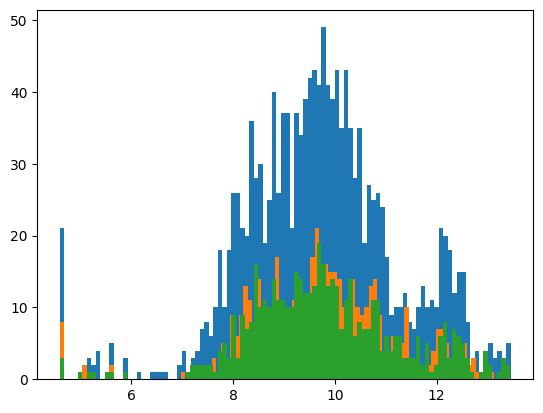

In [15]:
dim = 8
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);

### Converting to tensors

In [16]:
device = get_device()

Using cuda device


In [17]:
X_train = data_to_device(X_train, device)
y_train = data_to_device(y_train, device)
X_val = data_to_device(X_val, device)
y_val = data_to_device(y_val, device)
X_test = data_to_device(X_test, device)
y_test = data_to_device(y_test, device)

### Dataset

In [18]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [19]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Neural network

In [20]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): Dropout(p=0.07, inplace=False)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=256, bias=True)
    (5): Dropout(p=0.07, inplace=False)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1024, bias=True)
    (9): Dropout(p=0.07, inplace=False)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=1024, out_features=256, bias=True)
    (13): Dropout(p=0.07, inplace=False)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Linear(in_features=256, out_features=64, bias=True)
    (17): Dropout(p=0.07, inplace=False)
    (18): BatchNorm1d(64, eps=1

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [21]:
weights = torch.tensor([1/INPUT_SIZE]*INPUT_SIZE).unsqueeze(1).to(device)
loss_fn = CustomLoss(weights=weights)

In [23]:
model, train_losses, val_losses = train_model(model=model,
                                              train_loader=train_loader,
                                              val_loader=val_loader,
                                              epochs=5000,
                                              loss_fn=loss_fn)

EPOCH 1:
LOSS train 2.041757869720459 test 1.9699106135042797
EPOCH 2:
LOSS train 1.7132744153340658 test 1.5838563321345303
EPOCH 3:
LOSS train 1.448561469713847 test 1.2640366752343963
EPOCH 4:
LOSS train 1.2309266567230224 test 1.101119310740965
EPOCH 5:
LOSS train 1.0471588134765626 test 0.9373349812495182
EPOCH 6:
LOSS train 0.9008538166681925 test 0.8218659797466423
EPOCH 7:
LOSS train 0.7899523536364238 test 0.7302246427679636
EPOCH 8:
LOSS train 0.7113278627395629 test 0.6783895601769049
EPOCH 9:
LOSS train 0.654186999797821 test 0.6359839163211933
EPOCH 10:
LOSS train 0.6221067468325298 test 0.6074577581032692
EPOCH 11:
LOSS train 0.6029917518297832 test 0.6162164463515741
EPOCH 12:
LOSS train 0.5892274300257365 test 0.6094021045539274
EPOCH 13:
LOSS train 0.5687906622886658 test 0.5885349661710272
EPOCH 14:
LOSS train 0.5589857657750448 test 0.5951911129326706
EPOCH 15:
LOSS train 0.5521624724070231 test 0.5886244431257727
EPOCH 16:
LOSS train 0.5420881092548371 test 0.569964

In [ ]:
model, train_losses, val_losses = train_model(model=model,
                                              train_loader=train_loader,
                                              val_loader=val_loader,
                                              epochs=5000,
                                              loss_fn=loss_fn)

### Loss visualisation

In [ ]:
#%matplotlib widget

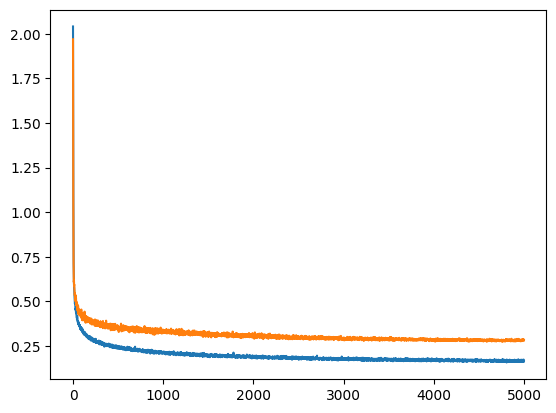

In [25]:
visualise_losses(train_losses, val_losses)

In [ ]:
visualise_losses(train_losses, val_losses)

## Loading pretrained model

In [22]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
model.load_state_dict(torch.load(MODELS_PATH))

/tmp/ipykernel_5151/2341782259.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODELS_PATH))


<All keys matched successfully>

## Prediction on test set

In [23]:
labels, outputs, difference, mean_loss = evaluate_on_test_set(model=model, 
                                                              test_loader=test_loader, 
                                                              loss_fn=loss_fn)

Consecutive inks from test set are in labels tensor (498 examples, 10 elements/coordinates):

In [24]:
labels

tensor([[ -3.9144,  -5.3428, -10.2555,  ...,  -9.9935,  -5.8202,   7.9321],
        [ -4.5463,  -4.0462, -11.4870,  ...,  -5.4306,  -5.8937,   9.7379],
        [ -1.5278,  -5.1578,  -9.5356,  ...,  -8.1900,  -2.6869,  10.2979],
        ...,
        [ -2.6264,  -3.1683,  -6.7505,  ...,  -6.4705,  -3.6345,   7.9865],
        [ -4.5004,  -5.5150, -11.2800,  ...,  -7.5645,  -5.6301,   9.0391],
        [ -4.6146,  -6.1749, -10.4120,  ...,  -6.3077,  -5.4435,   9.0797]],
       device='cuda:0')

Predictions are in out tensor (498 examples, 10 elements/coordinates):

In [25]:
outputs

tensor([[ -4.0141,  -5.3081, -10.1009,  ..., -10.3431,  -5.8479,   8.4087],
        [ -4.7156,  -4.0247, -11.3856,  ...,  -5.4171,  -5.8623,   9.8126],
        [ -1.6231,  -5.2754,  -8.8899,  ...,  -8.0668,  -2.5449,  10.0856],
        ...,
        [ -0.6074,  -4.5666,  -7.4492,  ...,  -6.7298,  -4.0734,   7.5223],
        [ -4.6195,  -5.5692,  -9.9515,  ...,  -7.4871,  -5.7001,   9.0849],
        [ -4.6490,  -6.2443, -10.7812,  ...,  -6.0433,  -5.5750,   9.1863]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (labels) and prediction (outputs) are stored in difference tensor (498 examples, 10 elements/coordinates):

In [26]:
#difference

Mean loss:

In [27]:
mean_loss

0.20079767110806154

In [28]:
torch.mean(difference, axis=0)  # 9 elements, new data

tensor([0.1921, 0.1728, 0.4160, 0.1195, 0.1948, 0.1831, 0.2052, 0.1610, 0.1629],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

## Saving the model

In [30]:
# save_model(model, MODELS_PATH, HOW_MANY_OUTER_TO_REMOVE, 
#                 ELEMENTS_TO_KEEP, PREPROCESSING_METHOD)

### Visualisations

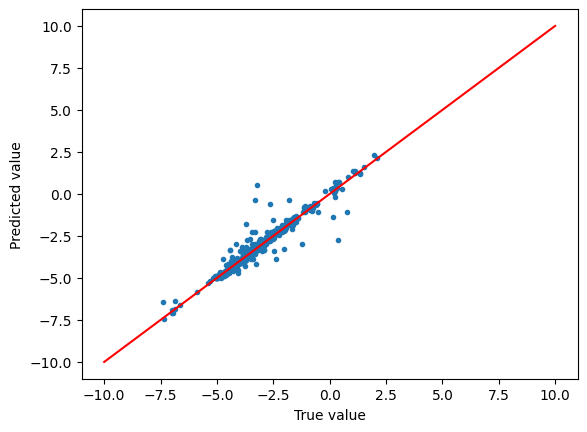

In [29]:
visualise_prediction_against_true(outputs, labels, dimension=0)

## Quality of prediction: closest points

### Creating df with means of classes

In [29]:
mean_df = create_means_df(ELEMENTS_TO_KEEP_NO_FE, y_train.cpu(), train_order, y_val.cpu(), val_order)

### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [30]:
y_test_df, consistency = find_and_compare_closest_class(y_test.cpu(), test_order, ELEMENTS_TO_KEEP_NO_FE, mean_df)

In [31]:
consistency

0.9678714859437751

### Now let's check if it works for the neural network's output.

In [32]:
model.eval()
outputs = model(X_test)

In [33]:
outputs_df, accuracy = find_and_compare_closest_class(outputs.cpu().detach().numpy(), test_order, ELEMENTS_TO_KEEP_NO_FE, mean_df)

In [34]:
accuracy = compute_accuracy(outputs_df)

Accuracy: 90.8%.


In [34]:
precision, recall = compute_precision_and_recall(outputs_df)

Precision: 0.9248837209302326
Recall: 0.9032428355957768


/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:193: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:194: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


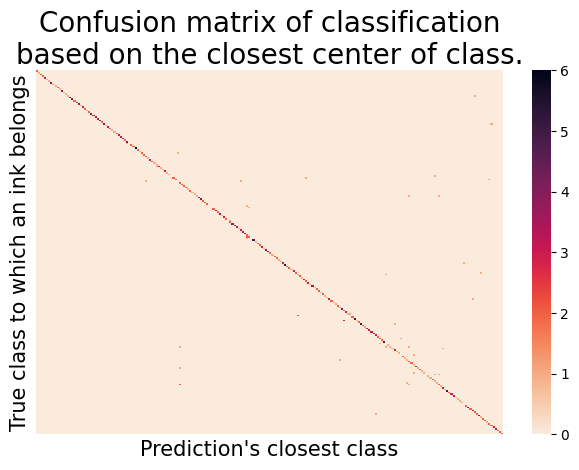

In [35]:
plot_confusion_matrix(true_labels = outputs_df['Real sample_id'], 
                      closest_labels = outputs_df['Closest sample id'], 
                      normalization_in_conf_mat = None, 
                      path_to_save = FIGURES_PATH)

## Quality of prediction: confidence intervals

In [42]:
model.eval()
outputs = model(X_test)

In [43]:
min_df, max_df, min_max_df = create_min_max_df(y_train.cpu(), 
                                               train_order, 
                                               y_val.cpu(), 
                                               val_order, 
                                               ELEMENTS_TO_KEEP_NO_FE)

In [44]:
lower_bound_df, upper_bound_df = create_mean_plus_sd_df(y_train.cpu(), 
                                                        train_order, 
                                                        y_val.cpu(), 
                                                        val_order, 
                                                        ELEMENTS_TO_KEEP_NO_FE, 
                                                        how_many_sd=2)

In [45]:
min_max_res_list, fraction_1 = is_inside_min_max_interval(outputs, test_order, min_df, max_df)

In [46]:
sd_res_list, fraction_2 = is_inside_mean_plus_minus_sd_interval(outputs, test_order, lower_bound_df, upper_bound_df)

Percentage of points inside min-max interval:

In [47]:
fraction_1

np.float64(0.6711289602855868)

On consecutive coordinates:

In [48]:
np.array(min_max_res_list).mean(0)

array([[0.6686747 , 0.72690763, 0.79317269, 0.58835341, 0.6626506 ,
        0.56024096, 0.70281124, 0.65261044, 0.68473896]])

Percentage of points inside mean +- 2 standard deviations interval:

In [49]:
fraction_2

np.float64(0.7902721999107541)

On consecutive coordinates:

In [50]:
np.array(sd_res_list).mean(0)

array([[0.76907631, 0.85943775, 0.87148594, 0.74297189, 0.80923695,
        0.67269076, 0.80321285, 0.78313253, 0.80120482]])

### Visualisations of min-max intervals

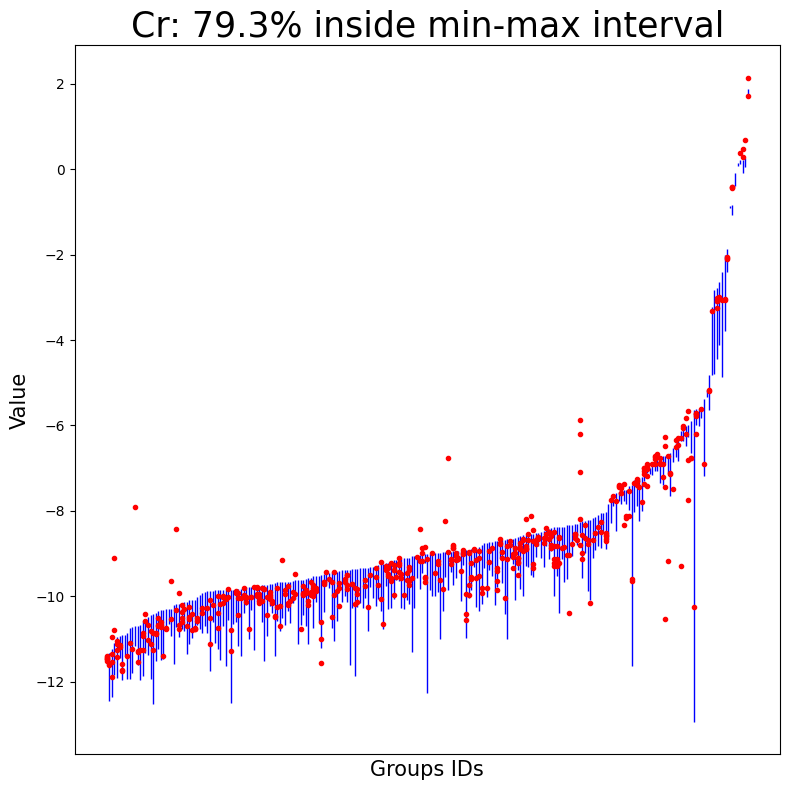

In [51]:
visualise_min_max_intervals(outputs, 
                            test_order, 
                            ELEMENTS_TO_KEEP_NO_FE, 
                            min_max_df, 
                            min_max_res_list, 
                            element_nr=2, 
                            path_to_save=None)

### Visualisations of mean +- 2 * standard deviation intervals

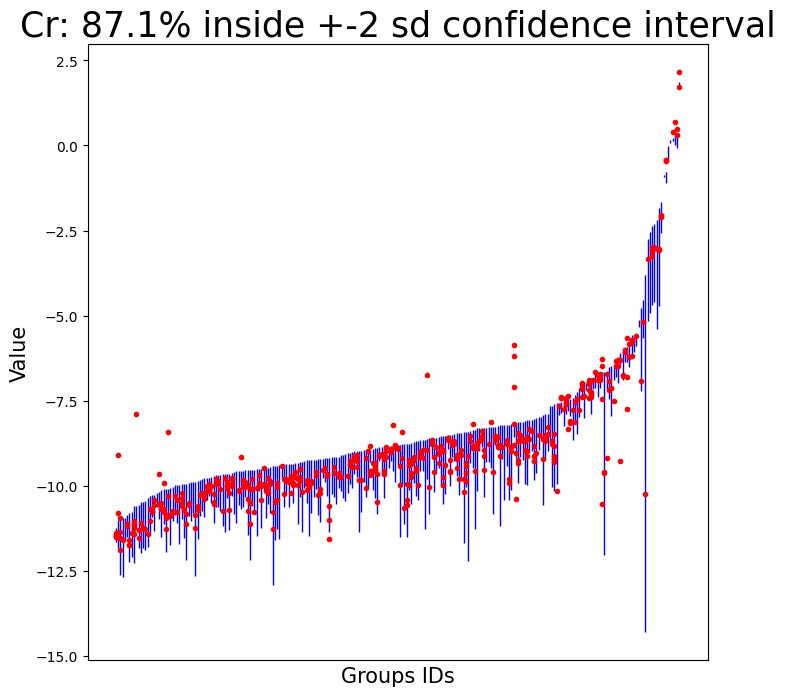

In [52]:
visualise_mean_plus_minus_sd_intervals(outputs, 
                                       test_order, 
                                        ELEMENTS_TO_KEEP_NO_FE, 
                                       lower_bound_df, 
                                       upper_bound_df, 
                                       how_many_sd=2,
                                       sd_res_list=sd_res_list, 
                                       element_nr=2, 
                                       path_to_save=None)